In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import cv2
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
from pathlib import Path
from PIL import Image

DEVICE = torch.device('cpu')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path('D:/ScanO-assign-Apaar')
DATA_DIR   = BASE_DIR / 'dataset'
TEST_DIR   = DATA_DIR / 'test'
OUT_DIR    = BASE_DIR / 'Exp3' / 'outputs'
SAMPLE_DIR = OUT_DIR / 'sample_outputs'
METRICS_FILE = OUT_DIR / 'metrics.txt'

SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

TEST_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Setup complete.')

Setup complete.


In [2]:
def load_model(phase: int) -> nn.Module:
    """
    Rebuild DenseNet121 head matching the saved phase, then load weights.
    """
    model = models.densenet121(weights=None)  # No ImageNet weights needed at test time

    if phase in (1, 2):
        model.classifier = nn.Linear(1024, 2)
    else:  # Phase 3
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(1024, 2)
        )

    ckpt_path = OUT_DIR / f'best_model_phase{phase}.pth'
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    model.to(DEVICE)
    print(f'  Loaded: {ckpt_path}')
    return model


print('Model loader ready.')

Model loader ready.


In [3]:
class GradCAM:
    def __init__(self, model: nn.Module):
        self.model       = model
        self.gradients   = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        target_layer = self.model.features.denseblock4

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor: torch.Tensor, class_idx: int) -> np.ndarray:
        self.model.zero_grad()
        output = self.model(input_tensor)
        score  = output[0, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3)).squeeze()
        cams    = self.activations.squeeze()
        cam     = torch.relu((weights[:, None, None] * cams).sum(dim=0))
        cam     = cam.numpy()

        if cam.max() > 0:
            cam = cam / cam.max()
        return cam


def overlay_gradcam(original_img: np.ndarray, cam: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    h, w        = original_img.shape[:2]
    cam_resized = cv2.resize(cam, (w, h))
    heatmap     = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return (alpha * heatmap + (1 - alpha) * original_img).astype(np.uint8)


print('Grad-CAM ready.')

Grad-CAM ready.


In [4]:
def run_test_inference(model: nn.Module, test_dataset) -> tuple:
    """
    Run model on every test sample, return (file_paths, y_true, y_pred, confidences)
    """
    file_paths, y_true, y_pred, confidences = [], [], [], []

    with torch.no_grad():
        for img_path, label in tqdm(test_dataset.samples, desc='  Inference', leave=False):
            img    = Image.open(img_path).convert('RGB')
            tensor = TEST_TRANSFORM(img).unsqueeze(0).to(DEVICE)
            output = model(tensor)
            probs  = torch.softmax(output, dim=1).squeeze()
            pred   = probs.argmax().item()
            conf   = probs[pred].item()

            file_paths.append(img_path)
            y_true.append(label)
            y_pred.append(pred)
            confidences.append(conf)

    return file_paths, y_true, y_pred, confidences


def append_test_metrics(phase: int, y_true: list, y_pred: list, class_names: list):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    lines = [
        f'--- Phase {phase} | Test Set ---',
        f'Accuracy  : {acc:.4f}',
        f'Precision : {prec:.4f}',
        f'Recall    : {rec:.4f}',
        f'F1-Score  : {f1:.4f}',
        f'Confusion Matrix (rows=true, cols=pred):',
        f'Classes   : {class_names}',
        str(cm),
        ''
    ]
    with open(METRICS_FILE, 'a') as f:
        f.write('\n'.join(lines) + '\n')

    return acc, prec, rec, f1


print('Inference & metrics utilities ready.')

Inference & metrics utilities ready.


In [5]:
def save_test_gradcam_samples(
    phase: int,
    model: nn.Module,
    predictions_df: pd.DataFrame,
    class_names: list
):
    phase_dir = SAMPLE_DIR / f'phase{phase}_test'
    phase_dir.mkdir(parents=True, exist_ok=True)

    gradcam = GradCAM(model)
    model.eval()

    import matplotlib.cm as mplcm
    import matplotlib.colors as mcolors

    correct_df   = predictions_df[predictions_df['correct'] == True].copy()
    incorrect_df = predictions_df[predictions_df['correct'] == False].copy()

    top3_correct = correct_df.nlargest(3, 'confidence')

    if len(incorrect_df) >= 3:
        bottom3 = incorrect_df.nsmallest(3, 'confidence')
    else:
        n_needed = 3 - len(incorrect_df)
        fallback = correct_df.nsmallest(n_needed, 'confidence')
        bottom3  = pd.concat([incorrect_df, fallback])

    samples = [
        (top3_correct, 'correct'),
        (bottom3,      'wrong'),
    ]

    for subset_df, subset_tag in samples:
        for _, row in subset_df.iterrows():
            img_path = row['filepath']

            # ── Load original ─────────────────────────────────────────────────
            orig_pil  = Image.open(img_path).convert('RGB').resize((224, 224))
            orig      = np.array(orig_pil)                         # (224,224,3) uint8
            orig_gray = np.array(orig_pil.convert('L'))            # (224,224)   uint8

            # ── Grad-CAM ──────────────────────────────────────────────────────
            tensor = TEST_TRANSFORM(
                Image.open(img_path).convert('RGB')
            ).unsqueeze(0).to(DEVICE)
            tensor.requires_grad_(True)

            pred_idx = class_names.index(row['pred_label'])
            cam      = gradcam.generate(tensor, pred_idx)          # (7,7) float [0,1]
            cam_224  = cv2.resize(cam, (224, 224))                 # (224,224) float

            # ── Heatmap (JET, float) ──────────────────────────────────────────
            jet      = mplcm.get_cmap('jet')
            heatmap  = jet(cam_224)[:, :, :3]                     # (224,224,3) float [0,1]

            # ── Overlay ───────────────────────────────────────────────────────
            alpha   = 0.5
            orig_f  = orig.astype(np.float32) / 255.0
            overlay = np.clip(alpha * heatmap + (1 - alpha) * orig_f, 0, 1)

            # ── 3-panel figure: Original | Grad-CAM | Overlay ─────────────────
            fig = plt.figure(figsize=(13, 4))
            gs  = fig.add_gridspec(
                1, 4,
                width_ratios=[1, 1, 0.06, 1],
                wspace=0.08
            )
            ax0  = fig.add_subplot(gs[0])
            ax1  = fig.add_subplot(gs[1])
            axcb = fig.add_subplot(gs[2])
            ax2  = fig.add_subplot(gs[3])

            # Panel 0 — Original
            ax0.imshow(orig_gray, cmap='gray', vmin=0, vmax=255)
            ax0.set_title('Original', fontsize=11, pad=6)
            ax0.axis('off')

            # Panel 1 — Grad-CAM heatmap
            ax1.imshow(cam_224, cmap='jet', vmin=0, vmax=1)
            ax1.set_title('Grad-CAM', fontsize=11, pad=6)
            ax1.axis('off')

            # Colorbar
            norm = mcolors.Normalize(vmin=0, vmax=1)
            sm   = plt.cm.ScalarMappable(cmap='jet', norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, cax=axcb)
            cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
            cbar.ax.tick_params(labelsize=8)

            # Panel 2 — Overlay
            ax2.imshow(overlay)
            ax2.set_title('Overlay', fontsize=11, pad=6)
            ax2.axis('off')

            fig.text(
                0.5, 0.01,
                f'True: {row["true_label"]}  |  Pred: {row["pred_label"]}  |  Conf: {row["confidence"]:.4f}  |  Phase {phase}',
                ha='center', fontsize=9, color='#444444'
            )

            plt.subplots_adjust(bottom=0.10)

            # Naming: test_gradcam_{correct|wrong}_true{label}_pred{label}_{index}.png
            import re as _re
            true_tag = row['true_label'].replace(' ', '')
            pred_tag = row['pred_label'].replace(' ', '')
            stem     = os.path.splitext(row['filename'])[0]
            m        = _re.search(r'(\d+)$', stem)
            idx_str  = m.group(1) if m else stem
            fname = phase_dir / f'test_gradcam_{subset_tag}_true{true_tag}_pred{pred_tag}_{idx_str}.png'
            plt.savefig(fname, dpi=120, bbox_inches='tight')
            plt.close()

    print(f'  Grad-CAM test samples saved → {phase_dir}')


print('Grad-CAM saver ready.')

Grad-CAM saver ready.


In [6]:
# Load test dataset (transform applied per-sample in inference loop)
test_dataset = datasets.ImageFolder(root=str(TEST_DIR), transform=TEST_TRANSFORM)
class_names  = test_dataset.classes
print(f'Test set: {len(test_dataset)} samples | Classes: {class_names}')

# Append test section header to metrics.txt
with open(METRICS_FILE, 'a') as f:
    f.write('\n=== TEST SET EVALUATION ===\n\n')

summary_rows = []

for phase in [1, 2, 3]:
    print(f'\n{"="*60}')
    print(f'  PHASE {phase} — Test Evaluation')
    print(f'{"="*60}')

    model = load_model(phase)

    file_paths, y_true, y_pred, confidences = run_test_inference(model, test_dataset)

    # Save predictions CSV
    df = pd.DataFrame({
        'filename'   : [os.path.basename(p) for p in file_paths],
        'filepath'   : file_paths,
        'true_label' : [class_names[t] for t in y_true],
        'pred_label' : [class_names[p] for p in y_pred],
        'confidence' : [round(c, 4) for c in confidences],
        'correct'    : [t == p for t, p in zip(y_true, y_pred)],
    })
    csv_path = OUT_DIR / f'predictions_phase{phase}_test.csv'
    df.to_csv(csv_path, index=False)
    print(f'  Predictions CSV saved → {csv_path}')

    # Metrics
    acc, prec, rec, f1 = append_test_metrics(phase, y_true, y_pred, class_names)
    print(f'  Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')

    summary_rows.append({'Phase': phase, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

    # Grad-CAM
    print('  Generating Grad-CAM...')
    save_test_gradcam_samples(phase, model, df, class_names)

print('\nAll phases evaluated.')

Test set: 160 samples | Classes: ['normal', 'pneumonia']

  PHASE 1 — Test Evaluation
  Loaded: D:\ScanO-assign-Apaar\Exp3\outputs\best_model_phase1.pth


  Predictions CSV saved → D:\ScanO-assign-Apaar\Exp3\outputs\predictions_phase1_test.csv
  Accuracy=0.9125  Precision=0.9135  Recall=0.9125  F1=0.9124
  Generating Grad-CAM...


C:\Users\apaar\AppData\Local\Temp\ipykernel_140792\2197927332.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet      = mplcm.get_cmap('jet')


  Grad-CAM test samples saved → D:\ScanO-assign-Apaar\Exp3\outputs\sample_outputs\phase1_test

  PHASE 2 — Test Evaluation
  Loaded: D:\ScanO-assign-Apaar\Exp3\outputs\best_model_phase2.pth


  Predictions CSV saved → D:\ScanO-assign-Apaar\Exp3\outputs\predictions_phase2_test.csv
  Accuracy=0.9125  Precision=0.9167  Recall=0.9125  F1=0.9123
  Generating Grad-CAM...


C:\Users\apaar\AppData\Local\Temp\ipykernel_140792\2197927332.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet      = mplcm.get_cmap('jet')


  Grad-CAM test samples saved → D:\ScanO-assign-Apaar\Exp3\outputs\sample_outputs\phase2_test

  PHASE 3 — Test Evaluation
  Loaded: D:\ScanO-assign-Apaar\Exp3\outputs\best_model_phase3.pth


  Predictions CSV saved → D:\ScanO-assign-Apaar\Exp3\outputs\predictions_phase3_test.csv
  Accuracy=0.9437  Precision=0.9444  Recall=0.9437  F1=0.9437
  Generating Grad-CAM...


C:\Users\apaar\AppData\Local\Temp\ipykernel_140792\2197927332.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet      = mplcm.get_cmap('jet')


  Grad-CAM test samples saved → D:\ScanO-assign-Apaar\Exp3\outputs\sample_outputs\phase3_test

All phases evaluated.



=== Test Set — Cross-Phase Summary ===
       Accuracy  Precision  Recall      F1
Phase                                     
1        0.9125     0.9135  0.9125  0.9124
2        0.9125     0.9167  0.9125  0.9123
3        0.9438     0.9444  0.9438  0.9437


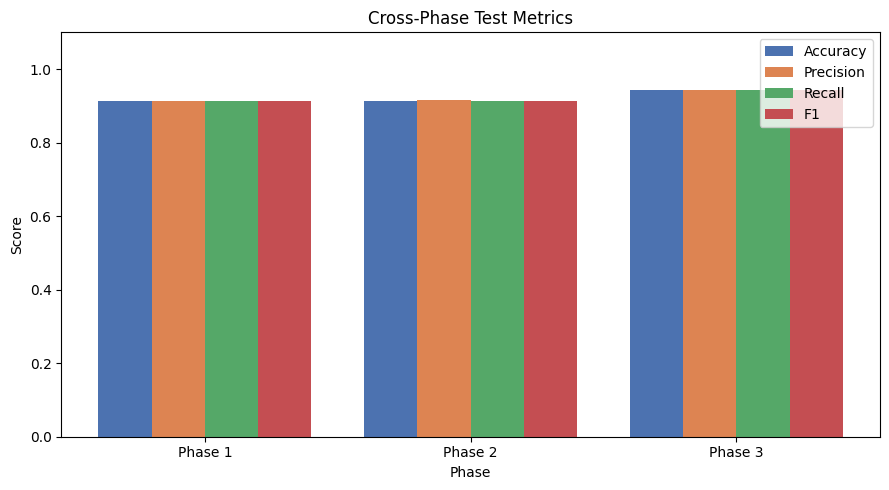

Comparison chart saved → D:\ScanO-assign-Apaar\Exp3\outputs\cross_phase_comparison.png


In [7]:
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index('Phase')
summary_df = summary_df.round(4)

print('\n=== Test Set — Cross-Phase Summary ===')
print(summary_df.to_string())

# Append to metrics.txt
with open(METRICS_FILE, 'a') as f:
    f.write('\n=== Cross-Phase Summary (Test Set) ===\n')
    f.write(summary_df.to_string())
    f.write('\n')

# Bar chart comparison
fig, ax = plt.subplots(figsize=(9, 5))
x      = np.arange(len(summary_df))
width  = 0.2
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (col, color) in enumerate(zip(metrics_cols, colors)):
    ax.bar(x + i * width, summary_df[col], width, label=col, color=color)

ax.set_xlabel('Phase')
ax.set_ylabel('Score')
ax.set_title('Cross-Phase Test Metrics')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'Phase {p}' for p in summary_df.index])
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()

chart_path = OUT_DIR / 'cross_phase_comparison.png'
plt.savefig(chart_path, dpi=100)
plt.show()
plt.close()
print(f'Comparison chart saved → {chart_path}')

In [8]:
with open(METRICS_FILE, 'r') as f:
    print(f.read())

=== DenseNet121 (pretrained on ImageNet) ===

--- Phase 1 | Validation ---
Accuracy  : 0.8854
Precision : 0.8855
Recall    : 0.8854
F1-Score  : 0.8854
Confusion Matrix (rows=true, cols=pred):
Classes   : ['normal', 'pneumonia']
[[41  6]
 [ 5 44]]

--- Phase 2 | Validation ---
Accuracy  : 0.8854
Precision : 0.8871
Recall    : 0.8854
F1-Score  : 0.8854
Confusion Matrix (rows=true, cols=pred):
Classes   : ['normal', 'pneumonia']
[[43  4]
 [ 7 42]]

--- Phase 3 | Validation ---
Accuracy  : 0.8958
Precision : 0.8966
Recall    : 0.8958
F1-Score  : 0.8958
Confusion Matrix (rows=true, cols=pred):
Classes   : ['normal', 'pneumonia']
[[43  4]
 [ 6 43]]


=== TEST SET EVALUATION ===

--- Phase 1 | Test Set ---
Accuracy  : 0.9125
Precision : 0.9135
Recall    : 0.9125
F1-Score  : 0.9124
Confusion Matrix (rows=true, cols=pred):
Classes   : ['normal', 'pneumonia']
[[71  9]
 [ 5 75]]

--- Phase 2 | Test Set ---
Accuracy  : 0.9125
Precision : 0.9167
Recall    : 0.9125
F1-Score  : 0.9123
Confusion Matri